In [ ]:
# 

In [ ]:
# 

In [ ]:
import pandas as pd
import tensorflow as tf
import numpy as np
import time as t
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array,load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D,AveragePooling2D ,Flatten, Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import RMSprop
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import fbeta_score, cohen_kappa_score, confusion_matrix
import cv2
import os

In [1]:
# Load the CSV file
train_csv_path = 'D:\\fracture_detection\\myenv\\train_image_paths_with_labels.csv'
train_data = pd.read_csv(train_csv_path)

valid_csv_path= 'D:\\fracture_detection\\myenv\\valid_image_paths_with_labels.csv'
valid_data=pd.read_csv(valid_csv_path)


In [ ]:
# train_data.drop(['path'],axis=1,inplace=True)

In [ ]:
negative_images=train_data[train_data['label']=='negative']
positive_images=train_data[train_data['label']=='positive']


In [ ]:
negative_images=negative_images.sample(n=len(positive_images),random_state=42)

In [ ]:
train_data=pd.concat([negative_images,positive_images])

In [ ]:
train_data=train_data.sample(frac=1)
valid_data=valid_data.sample(frac=1)

In [ ]:
train_data['label'].value_counts()

label
negative    14873
positive    14873
Name: count, dtype: int64

In [13]:

def show_image(data,label):
    print("Prining all images where fracture detection was :"+ label)
    plt.figure(figsize=[10,10])
    filtered_data=data[data['label']==label]
    file_paths=filtered_data['gray_image_path'].to_list()

    for i in range(20):
        _=plt.subplot(4,5,i+1)
        image_path=file_paths[i]
        img=plt.imread(image_path,cv2.IMREAD_GRAYSCALE)
        plt.imshow(img,cmap='gray')


In [14]:
gray_data=pd.read_csv("D:\\fracture_detection\\myenv\\grey_train_image_paths_with_labels.csv")

Prining all images where fracture detection was :positive


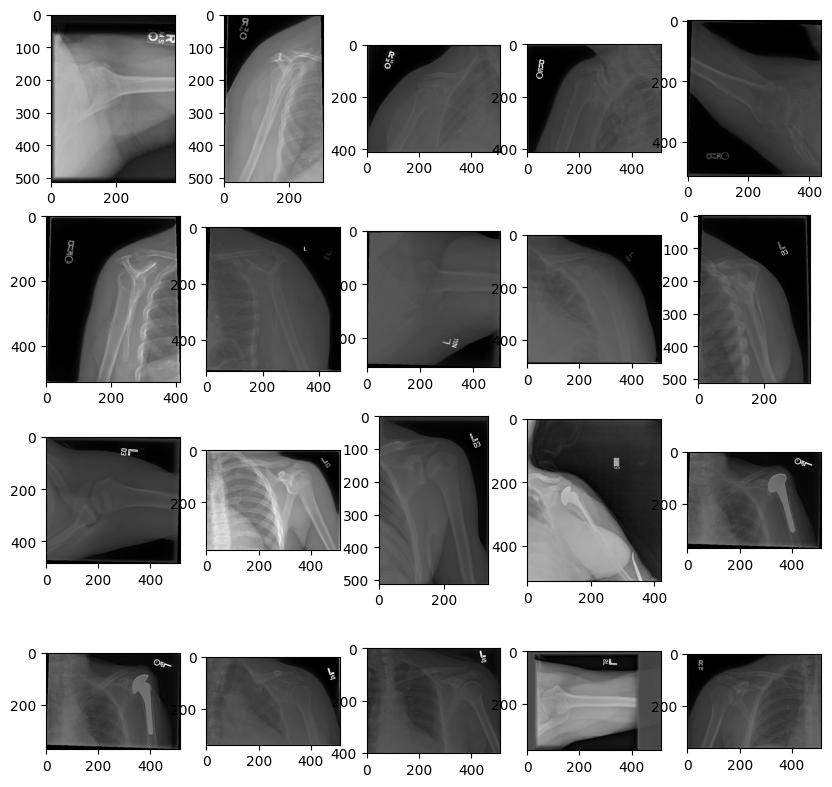

In [15]:
show_image(gray_data,'positive')

Prining all images where fracture detection was :negative


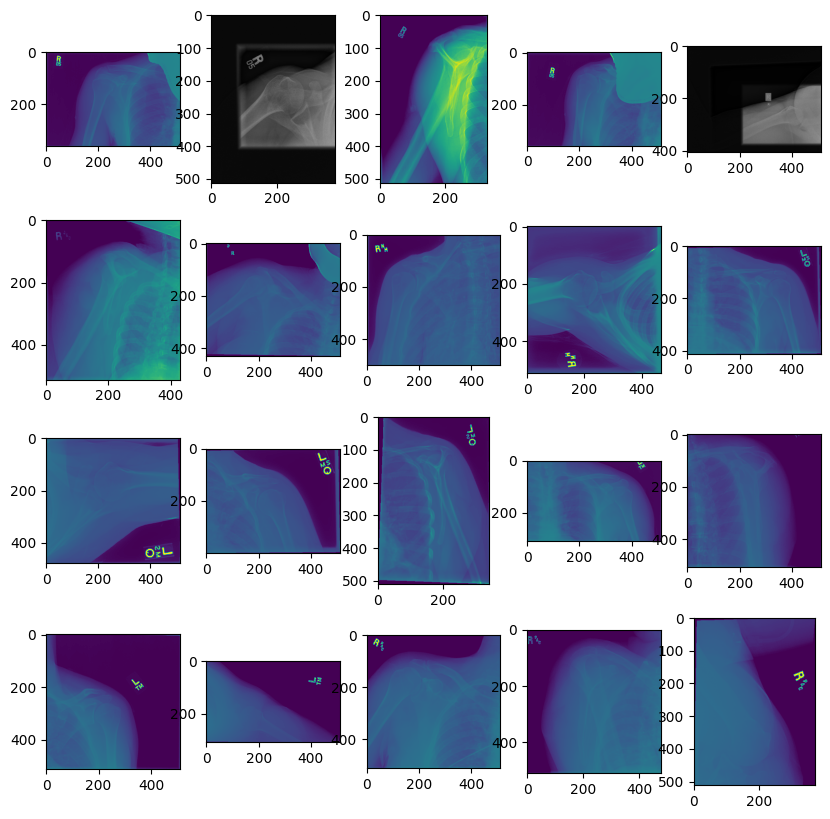

In [6]:
show_image(train_data,'positive')

In [ ]:

# Define image size for CNN input
IMG_SIZE = 128

def preprocess_image(image_path):
    # Read the grayscale image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    # Apply Scharr operator to find edges
    grad_x = cv2.Scharr(image, cv2.CV_64F, 1, 0)
    grad_y = cv2.Scharr(image, cv2.CV_64F, 0, 1)
    # Calculate the gradient magnitude
    edges = cv2.magnitude(grad_x, grad_y)
    # Convert to 8-bit
    edges = cv2.convertScaleAbs(edges)
    # Resize the image
    resized_edges = cv2.resize(edges, (IMG_SIZE, IMG_SIZE))
    return resized_edges

In [ ]:

def reshape_and_preprocess(data):
    # Prepare the dataset
    images = []
    labels = []

    for index, row in data.iterrows():
        gray_image_path = row['gray_image_path']
        label = row['label']
        
        # Preprocess image and append to list
        processed_image = preprocess_image(gray_image_path)
        images.append(processed_image)
        
        # Convert label to binary (0 for negative, 1 for positive)
        labels.append(1 if label == 'positive' else 0)

    # Convert lists to numpy arrays and normalize images
    images = np.array(images).reshape(-1, IMG_SIZE, IMG_SIZE, 1) / 255.0
    labels = np.array(labels)
    return images,labels


In [ ]:
train_images,train_labels=reshape_and_preprocess(train_data)


In [ ]:
valid_images,valid_labels=reshape_and_preprocess(valid_data)

In [ ]:
train_labels.shape

(29746,)

In [ ]:

# # Split dataset into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(train_images, train_labels, test_size=0.2, random_state=42)
X_train=train_images
y_train=train_labels

X_valid=valid_images
y_valid=valid_labels

# Convert labels to categorical format
y_train_categorical = to_categorical(y_train, num_classes=2)
#y_test_categorical = to_categorical(y_test, num_classes=2)
y_valid_categorical = to_categorical(y_valid, num_classes=2)


In [ ]:
y_train.shape

(29746,)

In [ ]:
valid_labels.shape

(3196,)

In [ ]:
from keras import layers
def create_seq_model():
    model = Sequential()

    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,1)))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2,2)))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2,2)))
    model.add(layers.Dropout(0.5))


    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=(2,2)))
    model.add(layers.Dropout(0.5))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(2, activation='softmax'))    # num_classes = 10

    # Checking the model summary
    model.summary()
    return model


In [ ]:
y_train.shape

(29746,)

In [ ]:
model=create_seq_model()

d:\fracture_detection\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,483,426 (17.10 MB)

 Trainable params: 4,482,274 (17.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:

# Compile the model
optimizer = RMSprop(learning_rate=0.001, rho=0.9)
model.compile(optimizer=optimizer,loss='binary_crossentropy', metrics=['accuracy'])



In [ ]:
import time as t
# Train the model
start_time=t.time()
history = model.fit(X_train, y_train_categorical, epochs=20, validation_data=(X_valid,y_valid_categorical))
end_time=t.time()
print("Training completed in time ",end_time-start_time," seconds")


Epoch 1/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 1213s 1s/step - accuracy: 0.5649 - loss: 0.7836 - val_accuracy: 0.5641 - val_loss: 0.7554
Epoch 2/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 1215s 1s/step - accuracy: 0.6437 - loss: 0.6313 - val_accuracy: 0.6358 - val_loss: 0.6559
Epoch 3/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 1209s 1s/step - accuracy: 0.6750 - loss: 0.5986 - val_accuracy: 0.6214 - val_loss: 0.6948
Epoch 4/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 1184s 1s/step - accuracy: 0.6879 - loss: 0.5822 - val_accuracy: 0.6079 - val_loss: 0.6932
Epoch 5/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 1187s 1s/step - accuracy: 0.7076 - loss: 0.5650 - val_accuracy: 0.6727 - val_loss: 0.5973
Epoch 6/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 1190s 1s/step - accuracy: 0.7158 - loss: 0.5511 - val_accuracy: 0.6427 - val_loss: 0.7185
Epoch 7/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 1190s 1s/step - accuracy: 0.7249 - loss: 0.5374 - val_accuracy: 0.6417 - val_loss: 0.6714
Epoch 8/20
930/930 ━━━━━━━━━━━━━━━━━━━━ 1193s 1s/step - accuracy: 0.7355 - loss: 0.5283 - 

In [ ]:
# Save the trained model
model.save('scharr_edge_wo_splitting_RMS.h5')

In [ ]:
# # Continue training the model for 50 more epochs
# history_more = model.fit(
#     X_train, y_train_categorical,
#     validation_data=(X_valid, y_valid_categorical),
#     epochs=50,  # Total epochs
#     initial_epoch=20  # Start from epoch 20
# )

In [ ]:

# Evaluate the model
loss, accuracy = model.evaluate(X_valid, y_valid_categorical)
print(f'Test accuracy: {accuracy:.4f}')


100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 207ms/step - accuracy: 0.6735 - loss: 0.7287
Test accuracy: 0.6849


In [ ]:
def plot_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(20)

    plt.figure(figsize=(15, 15))
    plt.subplot(2, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(2, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

In [ ]:
# Plotting confusion matrix
def conf_mat(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

In [ ]:
# Prediction and evaluation
def prediction_and_evaluation(model):
    predictions = model.predict(X_valid)
    pred = np.argmax(predictions, axis=1)
    
    # F beta score with beta=2
    beta = 2
    f_beta = fbeta_score(y_valid, pred, beta=beta)

    # Cohen's Kappa score
    kappa = cohen_kappa_score(y_valid, pred)
    
    print('\nf_beta score =', f_beta)
    print("Cohen's Kappa score =", kappa)
    print(classification_report(y_valid, pred, target_names=['Negative (Class 0)', 'Positive (Class 1)']))
    conf_mat(y_valid, pred)

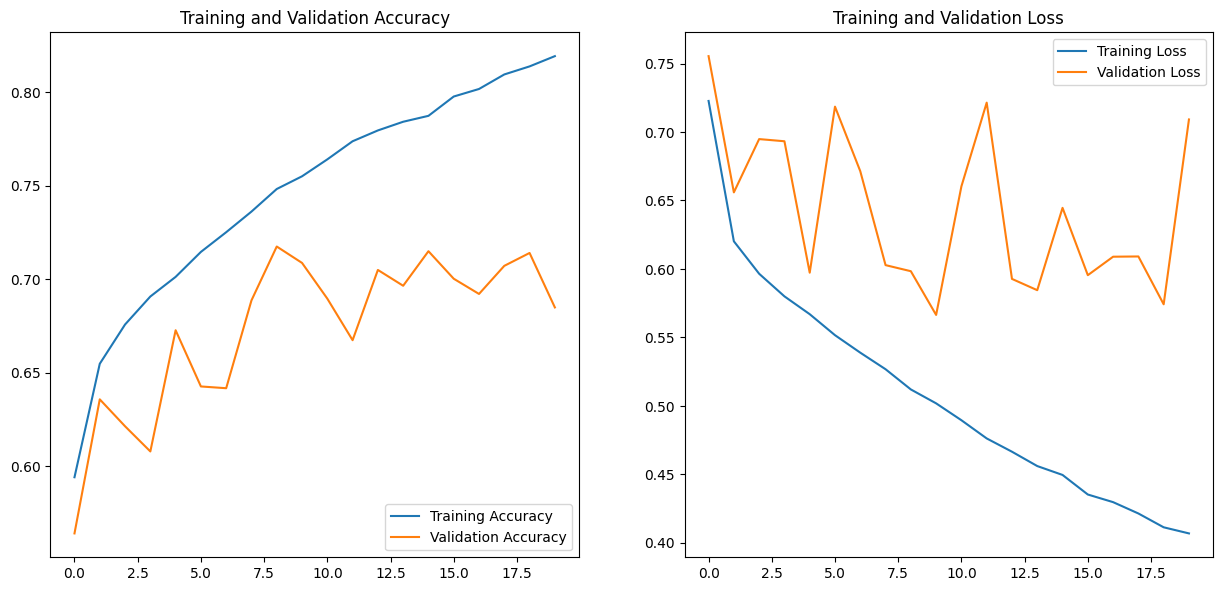

100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 193ms/step

f_beta score = 0.6070655116404982
Cohen's Kappa score = 0.3642370343446155
                    precision    recall  f1-score   support

Negative (Class 0)       0.67      0.78      0.72      1667
Positive (Class 1)       0.71      0.59      0.64      1529

          accuracy                           0.68      3196
         macro avg       0.69      0.68      0.68      3196
      weighted avg       0.69      0.68      0.68      3196



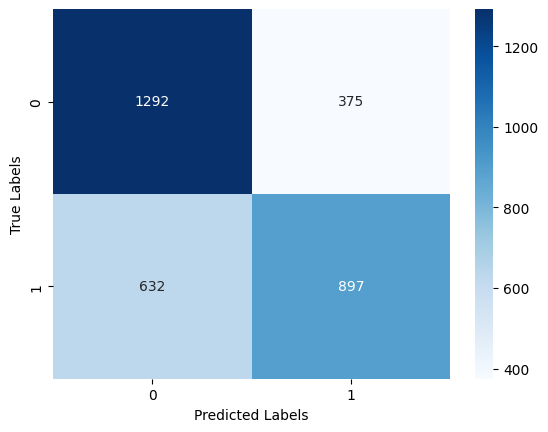

In [ ]:
plot_curves(history)
prediction_and_evaluation(model)

In [ ]:
def bar_chart(data):
    label_counts=data.value_counts()
    label=label_counts.index
    count=label_counts.values
    plt.figure(figsize=(8, 6))
    plt.bar(label,height=count, color=['blue', 'red'])
    plt.xlabel('Image Type')
    plt.ylabel('Count')
    plt.title('Distribution of Positive and Negative Images')
    plt.show()

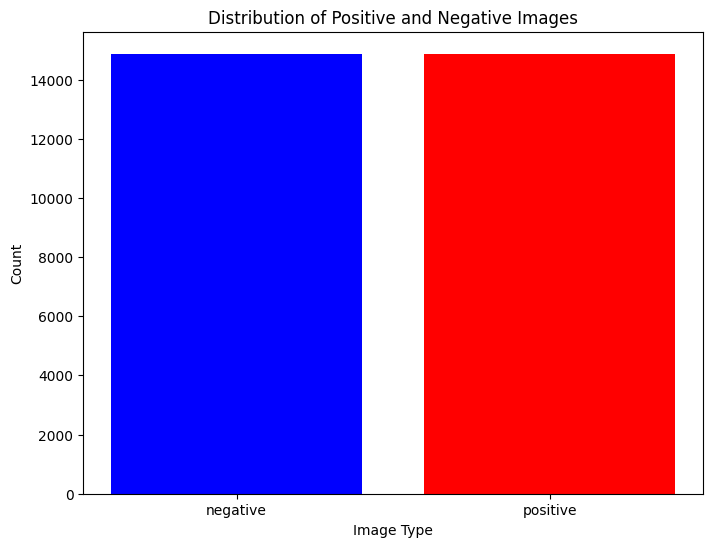

In [ ]:
bar_chart(train_data['label'])

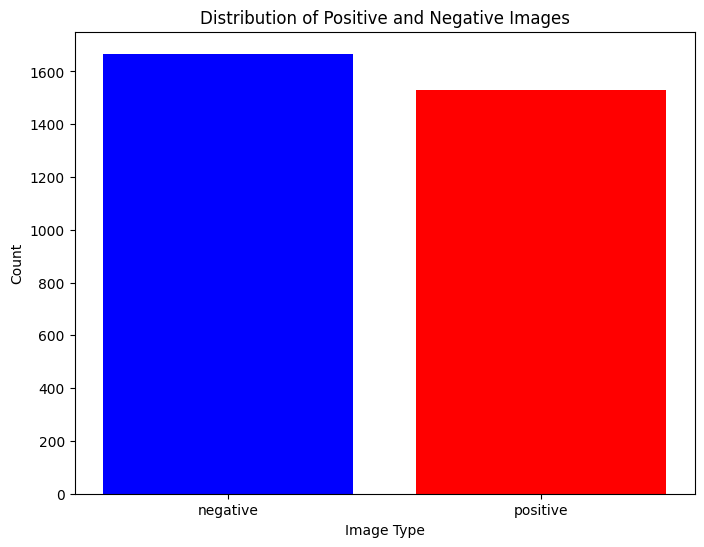

In [ ]:
bar_chart(valid_data['label'])

In [ ]:
train_data

,label,gray_image_path
22640,positive,MURA-v1.1/new_grey\gray_22640_image2.png
2269,positive,MURA-v1.1/new_grey\gray_2269_image2.png
29939,positive,MURA-v1.1/new_grey\gray_29939_image3.png
4062,positive,MURA-v1.1/new_grey\gray_4062_image4.png
27427,negative,MURA-v1.1/new_grey\gray_27427_image2.png
...,...,...
13429,negative,MURA-v1.1/new_grey\gray_13429_image1.png
3714,positive,MURA-v1.1/new_grey\gray_3714_image1.png
17030,negative,MURA-v1.1/new_grey\gray_17030_image2.png
31176,negative,MURA-v1.1/new_grey\gray_31176_image2.png


In [ ]:
valid_data

,label,gray_image_path
953,negative,MURA-v1.1/validtion_grey_scale\gray_953_image3...
2309,positive,MURA-v1.1/validtion_grey_scale\gray_2309_image...
1574,negative,MURA-v1.1/validtion_grey_scale\gray_1574_image...
1971,positive,MURA-v1.1/validtion_grey_scale\gray_1971_image...
1140,positive,MURA-v1.1/validtion_grey_scale\gray_1140_image...
...,...,...
2569,negative,MURA-v1.1/validtion_grey_scale\gray_2569_image...
118,positive,MURA-v1.1/validtion_grey_scale\gray_118_image1...
32,positive,MURA-v1.1/validtion_grey_scale\gray_32_image4.png
944,negative,MURA-v1.1/validtion_grey_scale\gray_944_image1...


In [ ]:
# train_data=train_data.drop('path')
# valid_data=valid_data.drop(['path'],axis=1)

Printing all images where fracture detection was: positive


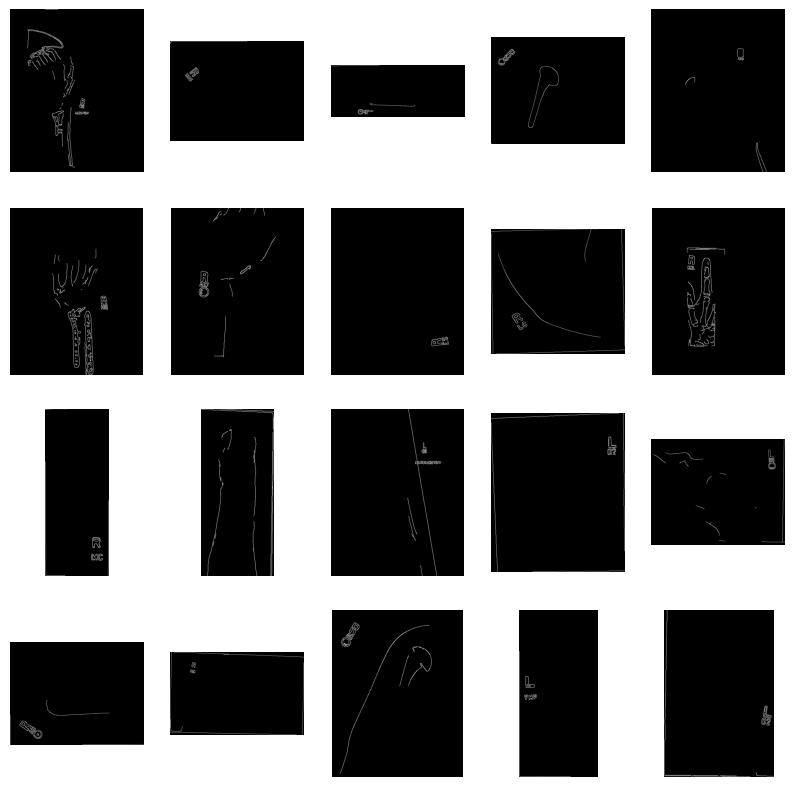

In [ ]:
import cv2
import matplotlib.pyplot as plt

def show_image(df, label):
    print(f"Printing all images where fracture detection was: {label}")
    plt.figure(figsize=[10, 10])
    filtered_data = df[df['label'] == label]
    file_paths = filtered_data['gray_image_path'].to_list()
    
    for i in range(min(20, len(file_paths))):  # Ensure no index out of range error
        plt.subplot(4, 5, i + 1)
        image_path = file_paths[i]
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Read as grayscale
        edge = cv2.Canny(img, 100, 200)
        plt.imshow(edge, cmap='gray')
        plt.axis('off')
    plt.show()

# Call the function to display images
show_image(train_data, 'positive')

Prining all images where fracture detection was :positive


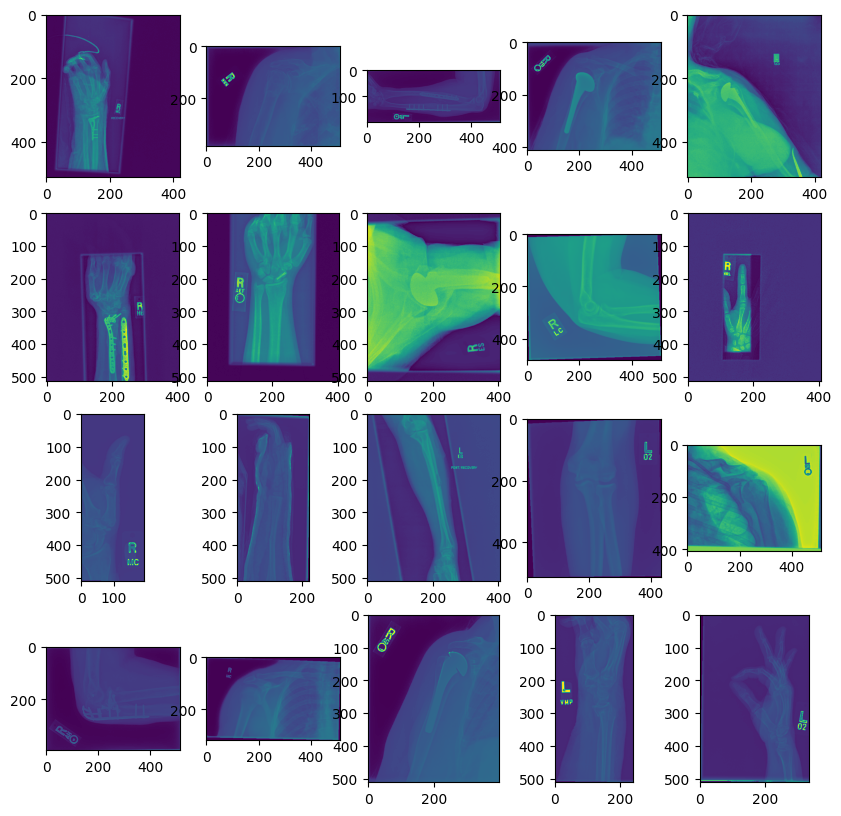

Prining all images where fracture detection was :negative


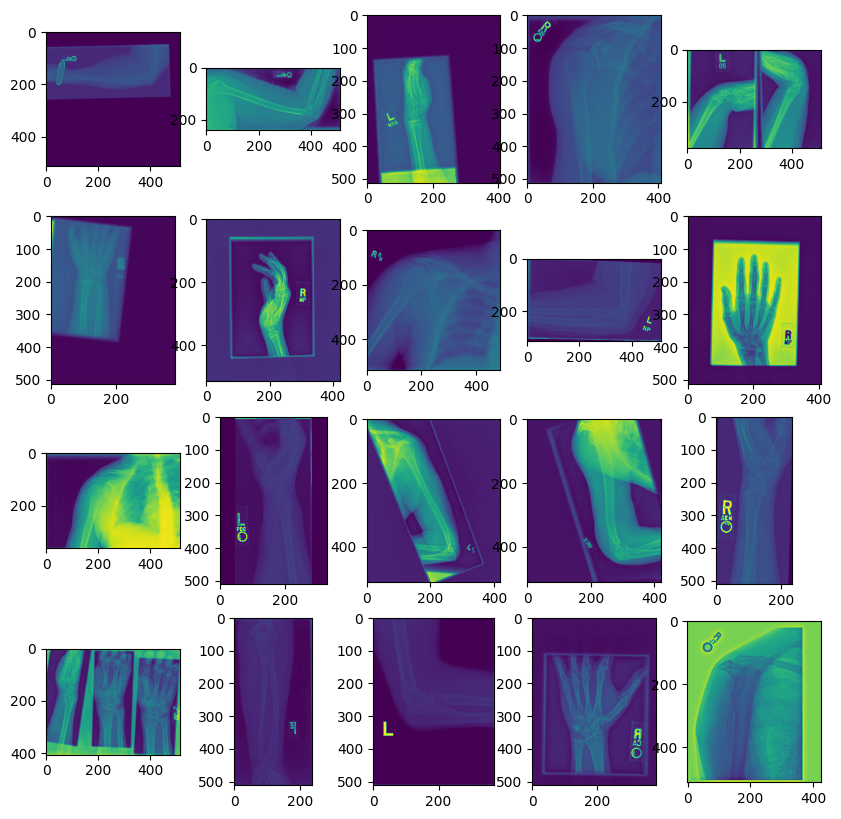

In [ ]:
show_image(valid_data,'negative')